# Model Explainability

## Objective

The objective of this notebook is to understand how the tuned Gradient Boosting Regressor makes predictions.

Model explainability helps identify the most influential features, understand individual predictions, and increase trust in the model.

This notebook uses:

- Feature Importance
- SHAP (SHapley Additive exPlanations)

In [1]:
# ==========================
# Import Libraries
# ==========================

import joblib
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import shap

In [2]:
# ==========================
# Load Model
# ==========================

model = joblib.load("../models/tuned_gradient_boosting.pkl")

X_train = joblib.load("../models/X_train_encoded.pkl")

X_test = joblib.load("../models/X_test_encoded.pkl")

y_test = joblib.load("../models/y_test.pkl")

In [3]:
# ==========================
# Feature Importance
# ==========================

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by = 'Importance',
    ascending = False
)

feature_importance.head(20)

,Feature,Importance
40,TotalSF,0.429069
4,OverallQual,0.278635
14,2ndFlrSF,0.026039
43,TotalBathrooms,0.025278
37,HouseAge,0.021652
26,GarageCars,0.019116
177,BsmtQual_Ex,0.018699
6,YearBuilt,0.016781
3,LotArea,0.015771
9,BsmtFinSF1,0.014831


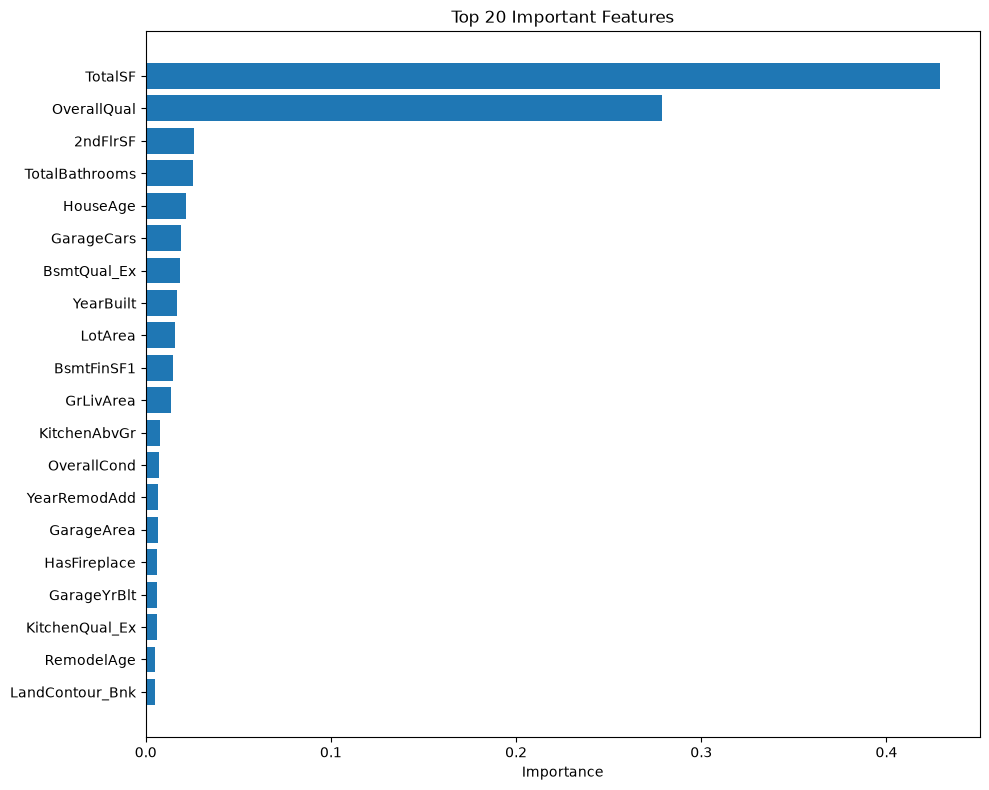

In [4]:
# ==========================
# Plotting Feature Importance
# ==========================

top20 = feature_importance.head(20)

plt.figure(figsize = (10, 8))

plt.barh(
    top20['Feature'],
    top20['Importance']
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")

plt.title("Top 20 Important Features")

plt.tight_layout()

plt.savefig(
    "../reports/figures/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [5]:
# ==========================
# Saving Importance to csv
# ==========================

feature_importance.to_csv(
    "../reports/results/feature_importance.csv",
    index=False
)

In [6]:
# ==========================
# SHAP Explainer
# ==========================

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

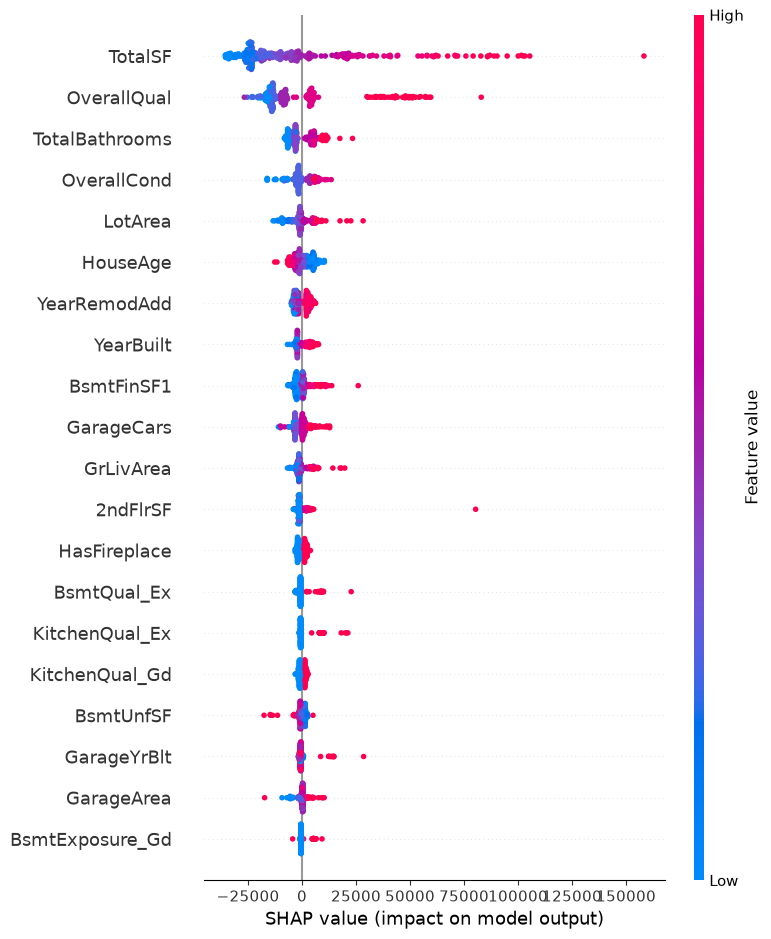

In [7]:
# ==========================
# SHAP Summary Plot
# ==========================

shap.summary_plot(shap_values, X_test, show = False)

plt.tight_layout()

plt.savefig(
    "../reports/figures/shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

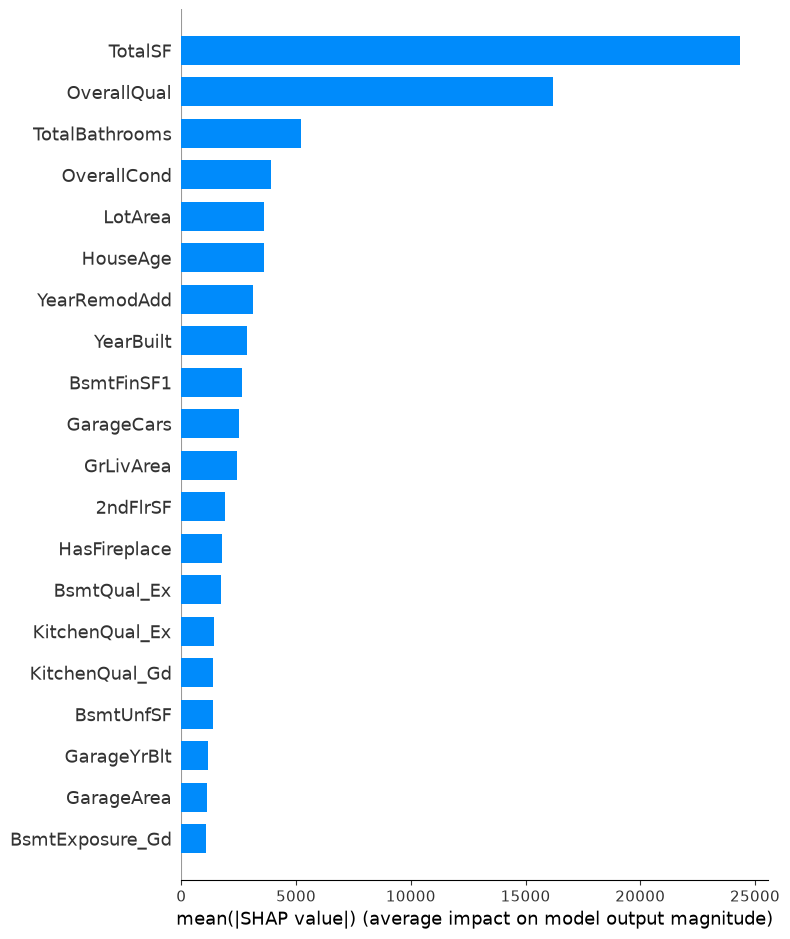

In [8]:
# ==========================
# SHAP Bar Plot
# ==========================

shap.summary_plot(shap_values, X_test, plot_type = 'bar', show = False)

plt.tight_layout()

plt.savefig(
    "../reports/figures/shap_bar_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

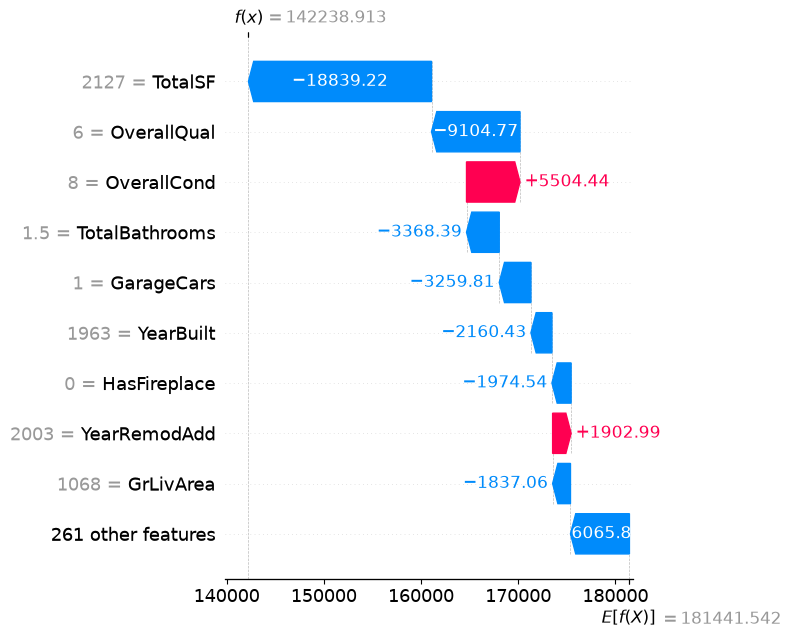

In [9]:
# ==========================
# Explain One Prediction
# ==========================

sample = 0

shap.waterfall_plot(
    shap.Explanation(
        values = shap_values[sample],
        base_values = explainer.expected_value[0],
        data = X_test.iloc[sample],
        feature_names = X_test.columns
    ),
    show = False
)

plt.tight_layout()

plt.savefig(
    "../reports/figures/shap_waterfall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
# ==========================
# Comparing Actual vs Prediction
# ==========================

prediction = model.predict(X_test.iloc[[sample]])[0]

print('Actual Price:', y_test.iloc[sample])
print('Predicted Price:', prediction)

Actual Price: 154500
Predicted Price: 142238.91345166604


# Conclusion

Feature importance and SHAP analysis were used to interpret the tuned Gradient Boosting Regressor.

The explainability analysis identified the most influential features affecting house prices and provided local explanations for individual predictions.

This improves model transparency and helps understand the reasoning behind predictions.